# SpiritAI Dataset Action Semantics Check

Load one LeRobot episode and compare `*_cmd_*` columns with matching `*_state_*` columns to see whether the dataset commands look like absolute targets or increments.

This notebook does not modify any training, serving, or dataset files.

In [1]:
from pathlib import Path

# Config is used only to print the active repo_id and extra_delta_transform setting.
CONFIG_NAME = "pi05_spiritai_lora"

# Set to None to resolve from CONFIG_NAME.repo_id under ~/.cache/huggingface/lerobot/.
# Default points to the local dataset that exists on this machine.
DATASET_DIR_OVERRIDE = Path("/home/dengkevin/Documents/dataset/20260512_FoldPaperBox_Moz1WB_MixedTask5+7_NoSlice_repaired")

# Use None to load the first available parquet file. Set an int to request a specific episode index.
EPISODE_INDEX = 29

# Columns to compare. The dimensions match the current SpiritAI action/state layout.
ACTION_STATE_PAIRS = [
    ("leftarm_cmd_joint_pos", "leftarm_state_joint_pos"),
    ("leftarm_cmd_psi", "leftarm_state_psi"),
    ("leftarm_gripper_cmd_pos", "leftarm_gripper_state_pos"),
    ("rightarm_cmd_joint_pos", "rightarm_state_joint_pos"),
    ("rightarm_cmd_psi", "rightarm_state_psi"),
    ("rightarm_gripper_cmd_pos", "rightarm_gripper_state_pos"),
    ("torso_cmd_joint_pos", "torso_state_joint_pos"),
    ("base_cmd_speed", "base_state_speed"),
]

EPS = 1e-9

In [2]:
import json
import os

import numpy as np
import pandas as pd

from openpi.training import config as _config


def resolve_dataset_dir(config_name: str, override: Path | None) -> Path:
    if override is not None:
        path = Path(override).expanduser().resolve()
        if not path.exists():
            raise FileNotFoundError(f"DATASET_DIR_OVERRIDE does not exist: {path}")
        return path

    cfg = _config.get_config(config_name)
    repo_id = cfg.data.repo_id
    if not repo_id:
        raise ValueError(f"Config {config_name} has no data.repo_id")

    candidates = [
        Path.home() / ".cache/huggingface/lerobot" / repo_id,
        Path.home() / ".cache/huggingface/lerobot" / repo_id.split("/")[-1],
        Path("/home/dengkevin/Documents/dataset") / repo_id.split("/")[-1],
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError("Could not resolve dataset dir. Set DATASET_DIR_OVERRIDE explicitly.")


config = _config.get_config(CONFIG_NAME)
dataset_dir = resolve_dataset_dir(CONFIG_NAME, DATASET_DIR_OVERRIDE)

print(f"Config      : {config.name}")
print(f"repo_id     : {config.data.repo_id}")
print(f"delta train : {getattr(config.data, 'extra_delta_transform', None)}")
print(f"Dataset dir : {dataset_dir}")

info_path = dataset_dir / "meta" / "info.json"
if info_path.exists():
    info = json.loads(info_path.read_text())
    video_keys = [k for k, v in info.get("features", {}).items() if v.get("dtype") == "video"]
    print(f"Video keys  : {len(video_keys)} -> {video_keys}")
else:
    info = {}
    print("No meta/info.json found")

Config      : pi05_spiritai_lora
repo_id     : spiritai/20260512_FoldPaperBox_350ep_34000stp
delta train : False
Dataset dir : /home/dengkevin/Documents/dataset/20260512_FoldPaperBox_Moz1WB_MixedTask5+7_NoSlice_repaired
Video keys  : 6 -> ['cam_high', 'cam_high_extra', 'cam_left_wrist', 'cam_left_wrist_extra', 'cam_right_wrist', 'cam_right_wrist_extra']


In [3]:
def episode_path(dataset_dir: Path, episode_index: int | None) -> Path:
    if episode_index is not None:
        chunk_size = int(info.get("chunks_size", 1000))
        chunk = episode_index // chunk_size
        requested = dataset_dir / "data" / f"chunk-{chunk:03d}" / f"episode_{episode_index:06d}.parquet"
        if requested.exists():
            return requested
        print(f"Requested episode not found: {requested}")

    files = sorted((dataset_dir / "data").glob("chunk-*/episode_*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet episodes found under {dataset_dir / 'data'}")
    print(f"Using first available parquet: {files[0]}")
    return files[0]


parquet_path = episode_path(dataset_dir, EPISODE_INDEX)
df = pd.read_parquet(parquet_path)

print(f"Episode parquet: {parquet_path}")
print(f"Rows x columns : {df.shape}")
print(f"episode_index  : {df['episode_index'].iloc[0] if 'episode_index' in df else 'N/A'}")
print(f"frame range    : {df['frame_index'].iloc[0]}..{df['frame_index'].iloc[-1]}" if 'frame_index' in df else "frame range    : N/A")
print("Columns:")
print(list(df.columns))

Episode parquet: /home/dengkevin/Documents/dataset/20260512_FoldPaperBox_Moz1WB_MixedTask5+7_NoSlice_repaired/data/chunk-000/episode_000029.parquet
Rows x columns : (1426, 31)
episode_index  : 29
frame range    : 0..1425
Columns:
['leftarm_cmd_cart_pos', 'leftarm_cmd_joint_pos', 'leftarm_state_cart_pos', 'leftarm_state_joint_pos', 'leftarm_cmd_psi', 'leftarm_state_psi', 'leftarm_gripper_cmd_pos', 'leftarm_gripper_state_pos', 'rightarm_cmd_cart_pos', 'rightarm_cmd_joint_pos', 'rightarm_state_cart_pos', 'rightarm_state_joint_pos', 'rightarm_cmd_psi', 'rightarm_state_psi', 'rightarm_gripper_cmd_pos', 'rightarm_gripper_state_pos', 'torso_cmd_cart_pos', 'torso_cmd_joint_pos', 'torso_state_cart_pos', 'torso_state_joint_pos', 'base_cmd_speed', 'base_state_speed', 'leftarm_cmd_global_cart_pos', 'rightarm_cmd_global_cart_pos', 'torso_cmd_global_cart_pos', 'frame_index', 'episode_index', 'timestamp', 'timestamp_perf', 'task_index', 'index']


In [4]:
def stack_col(frame: pd.DataFrame, key: str) -> np.ndarray:
    values = frame[key].to_numpy()
    first = values[0]
    if isinstance(first, np.ndarray):
        return np.stack(values).astype(np.float64)
    if isinstance(first, (list, tuple)):
        return np.asarray(values.tolist(), dtype=np.float64)
    return np.asarray(values, dtype=np.float64).reshape(len(values), -1)


def summarize_pair(action_key: str, state_key: str) -> dict:
    cmd = stack_col(df, action_key)
    state = stack_col(df, state_key)
    dim = min(cmd.shape[-1], state.shape[-1])
    cmd = cmd[:, :dim]
    state = state[:, :dim]

    same_state_err = np.abs(cmd - state)
    next_state_err = np.abs(cmd[:-1] - state[1:]) if len(df) > 1 else np.full_like(cmd, np.nan)
    state_step = state[1:] - state[:-1] if len(df) > 1 else np.full_like(cmd, np.nan)
    delta_err = np.abs(cmd[:-1] - state_step) if len(df) > 1 else np.full_like(cmd, np.nan)

    return {
        "action_key": action_key,
        "state_key": state_key,
        "dim": dim,
        "median_abs(cmd)": float(np.nanmedian(np.abs(cmd))),
        "median_abs(state)": float(np.nanmedian(np.abs(state))),
        "median_abs(state_step)": float(np.nanmedian(np.abs(state_step))),
        "median_abs(cmd-state_t)": float(np.nanmedian(same_state_err)),
        "median_abs(cmd-state_t+1)": float(np.nanmedian(next_state_err)),
        "median_abs(cmd-(state_t+1-state_t))": float(np.nanmedian(delta_err)),
        "p95_abs(cmd-state_t)": float(np.nanpercentile(same_state_err, 95)),
        "p95_abs(cmd-(state_t+1-state_t))": float(np.nanpercentile(delta_err, 95)),
    }


rows = []
for action_key, state_key in ACTION_STATE_PAIRS:
    if action_key not in df.columns or state_key not in df.columns:
        print(f"Skipping missing pair: {action_key}, {state_key}")
        continue
    rows.append(summarize_pair(action_key, state_key))

summary = pd.DataFrame(rows)
summary

,action_key,state_key,dim,median_abs(cmd),median_abs(state),median_abs(state_step),median_abs(cmd-state_t),median_abs(cmd-state_t+1),median_abs(cmd-(state_t+1-state_t)),p95_abs(cmd-state_t),p95_abs(cmd-(state_t+1-state_t))
0,leftarm_cmd_joint_pos,leftarm_state_joint_pos,7,0.639783,0.639783,0.000917,0.0000,0.000917,0.639777,0.000000,1.922002
1,leftarm_cmd_psi,leftarm_state_psi,1,5.657409,5.657409,0.001287,0.0000,0.001287,5.660361,0.000000,5.918359
2,leftarm_gripper_cmd_pos,leftarm_gripper_state_pos,1,0.000000,0.002600,0.000000,0.0026,0.002600,0.000000,0.053475,0.100000
3,rightarm_cmd_joint_pos,rightarm_state_joint_pos,7,0.453870,0.453870,0.000914,0.0000,0.000914,0.453922,0.000000,1.297635
4,rightarm_cmd_psi,rightarm_state_psi,1,0.908709,0.908709,0.001082,0.0000,0.001082,0.908838,0.000000,1.172705
5,rightarm_gripper_cmd_pos,rightarm_gripper_state_pos,1,0.000000,0.006100,0.000000,0.0061,0.006000,0.000000,0.067625,0.100000
6,torso_cmd_joint_pos,torso_state_joint_pos,6,0.364381,0.364381,0.000312,0.0000,0.000312,0.322403,0.000000,1.570443
7,base_cmd_speed,base_state_speed,3,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000069,0.000069


In [5]:
# Heuristic interpretation:
# - Absolute target: cmd magnitude is similar to state magnitude, and cmd is closer to state_t or state_t+1 than to state_step.
# - Increment/delta: cmd magnitude is similar to state_step, and cmd is closer to state_t+1-state_t.

if len(summary) == 0:
    raise RuntimeError("No action/state pairs were available for comparison.")

abs_err = summary[["median_abs(cmd-state_t)", "median_abs(cmd-state_t+1)"]].min(axis=1)
delta_err = summary["median_abs(cmd-(state_t+1-state_t))"]
cmd_mag = summary["median_abs(cmd)"]
state_mag = summary["median_abs(state)"]
step_mag = summary["median_abs(state_step)"]

verdict = summary[["action_key", "state_key", "dim"]].copy()
verdict["best_abs_err"] = abs_err
verdict["delta_err"] = delta_err
verdict["cmd/state_mag"] = cmd_mag / (state_mag + EPS)
verdict["cmd/state_step_mag"] = cmd_mag / (step_mag + EPS)
verdict["looks_like"] = np.where(delta_err < abs_err, "increment/delta-like", "absolute-like")

display(verdict)

counts = verdict["looks_like"].value_counts().to_dict()
print("Heuristic count:", counts)
print("")
print("Important: this checks raw dataset semantics only. Current pi05_spiritai_lora has extra_delta_transform=False,")
print("so openpi trains on the raw *_cmd_* values without converting them to cmd-state deltas.")

,action_key,state_key,dim,best_abs_err,delta_err,cmd/state_mag,cmd/state_step_mag,looks_like
0,leftarm_cmd_joint_pos,leftarm_state_joint_pos,7,0.0000,0.639777,1.0,697.315033,absolute-like
1,leftarm_cmd_psi,leftarm_state_psi,1,0.0000,5.660361,1.0,4395.864128,absolute-like
2,leftarm_gripper_cmd_pos,leftarm_gripper_state_pos,1,0.0026,0.000000,0.0,0.000000,increment/delta-like
3,rightarm_cmd_joint_pos,rightarm_state_joint_pos,7,0.0000,0.453922,1.0,496.490410,absolute-like
4,rightarm_cmd_psi,rightarm_state_psi,1,0.0000,0.908838,1.0,839.469215,absolute-like
5,rightarm_gripper_cmd_pos,rightarm_gripper_state_pos,1,0.0060,0.000000,0.0,0.000000,increment/delta-like
6,torso_cmd_joint_pos,torso_state_joint_pos,6,0.0000,0.322403,1.0,1166.711852,absolute-like
7,base_cmd_speed,base_state_speed,3,0.0000,0.000000,0.0,0.000000,absolute-like


Heuristic count: {'absolute-like': 6, 'increment/delta-like': 2}

Important: this checks raw dataset semantics only. Current pi05_spiritai_lora has extra_delta_transform=False,
so openpi trains on the raw *_cmd_* values without converting them to cmd-state deltas.


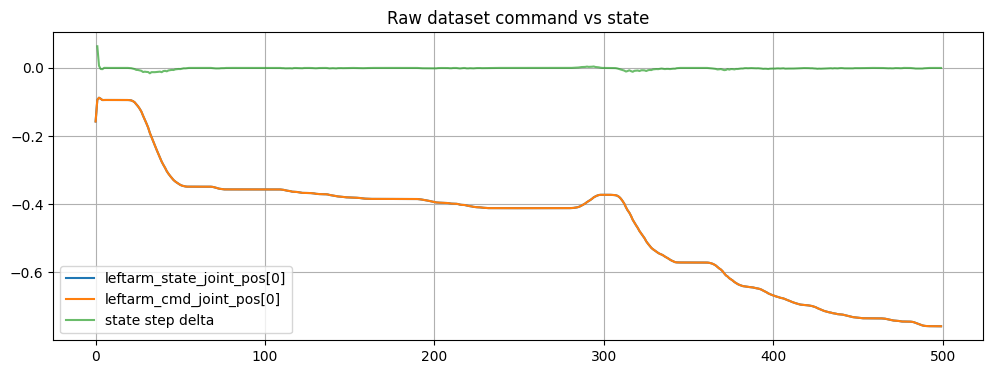

In [6]:
# Optional plot for one pair/dimension.
import matplotlib.pyplot as plt

PLOT_ACTION_KEY = "leftarm_cmd_joint_pos"
PLOT_STATE_KEY = "leftarm_state_joint_pos"
PLOT_DIM = 0
MAX_POINTS = 500

cmd = stack_col(df, PLOT_ACTION_KEY)[:MAX_POINTS, PLOT_DIM]
state = stack_col(df, PLOT_STATE_KEY)[:MAX_POINTS, PLOT_DIM]
state_step = np.r_[np.nan, np.diff(state)]

plt.figure(figsize=(12, 4))
plt.plot(state, label=f"{PLOT_STATE_KEY}[{PLOT_DIM}]")
plt.plot(cmd, label=f"{PLOT_ACTION_KEY}[{PLOT_DIM}]")
plt.plot(state_step, label="state step delta", alpha=0.7)
plt.legend()
plt.grid(True)
plt.title("Raw dataset command vs state")
plt.show()